<a href="https://colab.research.google.com/github/preetipss/ModelDeployment/blob/main/SuperKart_Model_Deployment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statement**

## Business Context

A sales forecast is a prediction of future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action.

Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast process has many benefits which include improved decision-making about the future and reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establish benchmarks that can be used to assess trends in the future.

## Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm—not just to build a predictive model based on historical sales data, but to develop and deploy a robust forecasting solution that can be integrated into SuperKart’s decision-making systems and used across its network of stores.

## Data Description

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that particular product in that particular store


# **Installing and Importing the necessary libraries**

In [1]:
#Installing the libraries with the specified versions
# !pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 xgboost==2.1.4 huggingface_hub==0.34.0 -q

!pip install -q \
    numpy==2.1.3 \
    pandas==2.2.3 \
    scikit-learn==1.6.1 \
    xgboost==2.1.4 \
    matplotlib==3.10.0 \
    seaborn==0.13.2 \
    joblib==1.6.0 \
    streamlit==1.43.2 \
    PyGithub==2.6.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.5/228.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 351.5/351.5 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.8/62.8 kB 1.1 MB/s eta 0:00:00


**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [2]:
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# For splitting the dataset
from sklearn.model_selection import train_test_split

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

# Libraries to get different metric scores
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# To create the pipeline
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline,Pipeline

# To tune different models and standardize
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder

# To serialize the model
import joblib

# os related functionalities
import os

# API request
import requests

# # for hugging face space authentication to upload files
# from huggingface_hub import login, HfApi

# for pushing deployment files to GitHub
from github import Github

# **Loading the dataset**

In [23]:
!git clone https://github.com/preetipss/ModelDeployment.git

Cloning into 'ModelDeployment'...
remote: Enumerating objects: 40, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 40 (delta 22), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (40/40), 647.48 KiB | 5.06 MiB/s, done.
Resolving deltas: 100% (22/22), done.


In [10]:
# Load the dataset from a CSV file into a Pandas DataFrame
import pandas as pd

df = pd.read_csv("/content/ModelDeployment/SuperKart.csv")

# Create a copy of the dataframe
data = df.copy()


# **Data Overview**

In [ ]:
# Display the first five rows of the dataset
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


In [ ]:
# checking shape of the data
print(f"There are {data.shape[0]} rows and {data.shape[1]} columns.")

There are 8763 rows and 12 columns.


In [ ]:
# Display the column names of the dataset
data.columns

Index(['Product_Id', 'Product_Weight', 'Product_Sugar_Content',
       'Product_Allocated_Area', 'Product_Type', 'Product_MRP', 'Store_Id',
       'Store_Establishment_Year', 'Store_Size', 'Store_Location_City_Type',
       'Store_Type', 'Product_Store_Sales_Total'],
      dtype='object')

In [ ]:
# checking column datatypes and number of non-null values
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   object 
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   object 
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   object 
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   object 
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   object 
 9   Store_Location_City_Type   8763 non-null   object 
 10  Store_Type                 8763 non-null   object 
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 821.7+ KB


In [ ]:
# checking for duplicate values
data.duplicated().sum()

np.int64(0)

In [ ]:
# checking for missing values
data.isnull().sum()

,0
Product_Id,0
Product_Weight,0
Product_Sugar_Content,0
Product_Allocated_Area,0
Product_Type,0
Product_MRP,0
Store_Id,0
Store_Establishment_Year,0
Store_Size,0
Store_Location_City_Type,0


**Observation**

- Product_Id,Product_Sugar_Content,Product_Type,Store_Id,Store_Size,Store_Location_City_Type,Store_Type are categorial variables.

- Product_Weight,Product_Allocated_Area,Product_MRP,Product_Store_Sales_Total are numerical variables.

- Store_Establishment_Year is currently a numerical variable but its indicating year which can help to calculate the store age.

- First 2 charecters of Product_id could give a categorization of products.

- There are no duplicate values in the data.

- There are no null values in the data.




# **Additional Variables**

In [40]:
# First 2 charecters of Product_id could give a categorization of products.
data['Product_Id_char'] = data['Product_Id'].str[:2]
data['Product_Id_char'].value_counts()

,count
Product_Id_char,
FD,6539
NC,1519
DR,705


In [ ]:
#checking Product_Category against Product_Type
data.groupby('Product_Type')['Product_Id_char'].value_counts()

,,count
Product_Type,Product_Id_char,
Baking Goods,FD,716
Breads,FD,200
Breakfast,FD,106
Canned,FD,677
Dairy,FD,796
Frozen Foods,FD,811
Fruits and Vegetables,FD,1249
Hard Drinks,DR,186
Health and Hygiene,NC,628


There is a clear categorization here FD is Food, DR is Drinks/Beverages and NC is Non-Food/Non-Consumables.

In [41]:
data['Product_Category'] = data['Product_Id_char'].map({
    'FD': 'Food',
    'DR': 'Beverage',
    'NC': 'Non-Food'
})

data['Product_Category']

,Product_Category
0,Food
1,Food
2,Food
3,Food
4,Non-Food
...,...
8758,Non-Food
8759,Non-Food
8760,Non-Food
8761,Non-Food


In [ ]:
data.groupby('Product_Id_char')['Product_Type'].value_counts()

Product_Id_char  Product_Type         
DR               Soft Drinks               519
                 Hard Drinks               186
FD               Fruits and Vegetables    1249
                 Snack Foods              1149
                 Frozen Foods              811
                 Dairy                     796
                 Baking Goods              716
                 Canned                    677
                 Meat                      618
                 Breads                    200
                 Starchy Foods             141
                 Breakfast                 106
                 Seafood                    76
NC               Household                 740
                 Health and Hygiene        628
                 Others                    151
Name: count, dtype: int64

In [42]:
data['Product_Type_Category'] = data['Product_Id_char'].map({
    'FD': 'Perishables',
    'DR': 'Non Perishables',
    'NC': 'Non Perishables'
})

data['Product_Type_Category']

,Product_Type_Category
0,Perishables
1,Perishables
2,Perishables
3,Perishables
4,Non Perishables
...,...
8758,Non Perishables
8759,Non Perishables
8760,Non Perishables
8761,Non Perishables


In [43]:
# Store age basis Store_Establishment_Year
from datetime import datetime

current_year = datetime.now().year

data['Store_Age_Years'] = current_year - data['Store_Establishment_Year']

In [ ]:
#Age distribution
data['Store_Age_Years'].value_counts()

,count
Store_Age_Years,
17,4676
39,1586
27,1349
28,1152


In [ ]:
#Distribution of age against Store_Id
data.groupby('Store_Id')['Store_Age_Years'].value_counts()

,,count
Store_Id,Store_Age_Years,
OUT001,39,1586
OUT002,28,1152
OUT003,27,1349
OUT004,17,4676


In [ ]:
#Distribution of age against Store_Id
data.groupby(['Store_Id','Store_Type'])['Store_Age_Years'].value_counts()

,,,count
Store_Id,Store_Type,Store_Age_Years,
OUT001,Supermarket Type1,39,1586
OUT002,Food Mart,28,1152
OUT003,Departmental Store,27,1349
OUT004,Supermarket Type2,17,4676


**Observation**

- Since Store_Type is already giving the information on the type of store so Store_ID can be dropped.

- additional information has already been extracted from Product_ID so it too can be dropped.

- Since there are 4 Store_ID/Store_Type so age is distributed in just 4 values, so we will use it as it is.

- Since Product_Type_Category is being considered so we can drop Product_Type.

# **Exploratory Data Analysis (EDA)**

Let's start by defining the target and predictor (numerical and categorical) variables.

In [45]:
# Define the target variable for the regression task
target = 'Product_Store_Sales_Total'

# List of numerical features in the dataset (excluding 'id' as it is an identifier)
numeric_features = [
    'Product_Weight',
    'Product_Allocated_Area',
    'Product_MRP',
    'Store_Age_Years'
]

# List of categorical features in the dataset
categorical_features = [
    'Product_Sugar_Content',
    'Product_Id_char',
    'Product_Type_Category',
    'Store_Size',
    'Store_Location_City_Type',
    'Store_Type'
]

## Univariate Analysis

In [ ]:
# Generate summary statistics for numerical features
data[numeric_features].describe()

,Product_Weight,Product_Allocated_Area,Product_MRP,Store_Age_Years
count,8763.000000,8763.000000,8763.000000,8763.000000
mean,12.653792,0.068786,147.032539,23.967249
std,2.217320,0.048204,30.694110,8.388381
min,4.000000,0.004000,31.000000,17.000000
25%,11.150000,0.031000,126.160000,17.000000
50%,12.660000,0.056000,146.740000,17.000000
75%,14.180000,0.096000,167.585000,28.000000
max,22.000000,0.298000,266.000000,39.000000


**Observation**
- Product Weight averages 12.65, with values ranging from 4 to 22, showing moderate variation.
- Product MRP averages 147.03, ranging from 31 to 266, indicating a wide price range.
- Product Allocated Area has a mean of 0.069, with values between 0.004 and 0.298.
- Store Age averages around 24 years, ranging from 17 to 39 years, indicating predominantly well-established stores.
- The median values suggest relatively stable distributions, although Product Allocated Area and MRP show noticeable variability.

In [ ]:
# Generate summary statistics for categorical features
data[categorical_features].describe()

,Product_Sugar_Content,Product_Id_char,Product_Type_Category,Store_Size,Store_Location_City_Type,Store_Type
count,8763,8763,8763,8763,8763,8763
unique,4,3,2,3,3,4
top,Low Sugar,FD,Perishables,Medium,Tier 2,Supermarket Type2
freq,4885,6539,6539,6025,6262,4676


In [ ]:
# Let's check the unique values for categorical variables

# list of all categorical variables
cat_col = data.select_dtypes(include="object").columns.tolist()

# printing the number of occurrences of each unique value in each categorical column
for column in cat_col:
    print(data[column].value_counts(normalize=True))
    print("-" * 50)

Product_Id
FD306     0.000114
FD6114    0.000114
FD7839    0.000114
FD5075    0.000114
FD8233    0.000114
            ...   
FD1387    0.000114
FD1231    0.000114
FD5276    0.000114
FD8553    0.000114
FD6027    0.000114
Name: proportion, Length: 8763, dtype: float64
--------------------------------------------------
Product_Sugar_Content
Low Sugar    0.557457
Regular      0.256875
No Sugar     0.173342
reg          0.012325
Name: proportion, dtype: float64
--------------------------------------------------
Product_Type
Fruits and Vegetables    0.142531
Snack Foods              0.131119
Frozen Foods             0.092548
Dairy                    0.090836
Household                0.084446
Baking Goods             0.081707
Canned                   0.077257
Health and Hygiene       0.071665
Meat                     0.070524
Soft Drinks              0.059226
Breads                   0.022823
Hard Drinks              0.021226
Others                   0.017232
Starchy Foods            0.016090

**Observation**

- **Product Sugar Content**: 56% of products are Low Sugar, followed by Regular (26%) and No Sugar (17%); a small 1.2% is recorded as "reg", indicating a possible data inconsistency.
- **Product Type**: Fruits & Vegetables (14.3%) and Snack Foods (13.1%) are the most common, while Seafood (0.9%) and Breakfast (1.2%) have relatively low representation.
- **Store Distribution**: OUT004 accounts for 53.4% of observations, while the remaining stores contribute 13–18% each, indicating store-level imbalance.
- **Store Characteristics**: Medium-sized stores dominate (68.8%), and Tier 2 cities account for 71.5% of observations.
- **Product Category**: Food is the dominant category (74.6%), followed by Non-Food (17.3%) and Beverage (8.0%).
- **Store Type**: Supermarket Type2 dominates the dataset with 53.4% of observations, followed by Supermarket Type1 (18.1%) and Departmental Stores (15.4%). Food Marts account for the remaining 13.1%, indicating a relatively uneven distribution across store types.
- **Product_Type_Category**: there are ~75% Perishables items and ~25% Non Perishables.

In [12]:
# Generate summary statistics for the target variable
data[target].describe()

,Product_Store_Sales_Total
count,8763.000000
mean,3464.003640
std,1065.630494
min,33.000000
25%,2761.715000
50%,3452.340000
75%,4145.165000
max,8000.000000


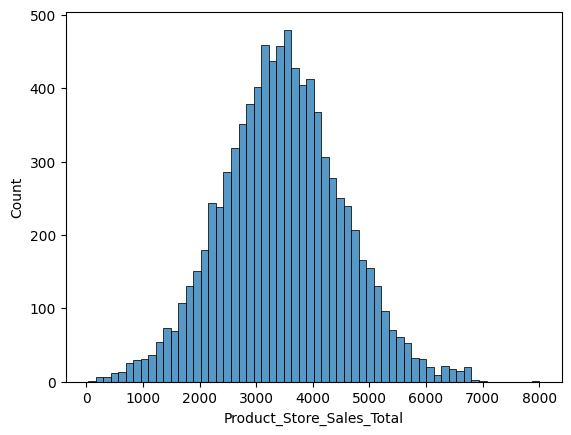

In [ ]:
# Check the distribution of the target variable
sns.histplot(data[target]);

**Observations**

- **Product_Store_Sales_Total** appears to be normally distributed ranging from 33 to 8000 with mean of 3464.

## Bivariate Analysis

In [ ]:
data.corr(numeric_only = True)

,Product_Weight,Product_Allocated_Area,Product_MRP,Store_Establishment_Year,Product_Store_Sales_Total,Store_Age_Years
Product_Weight,1.000000,0.014754,0.532716,-0.161907,0.737955,0.161907
Product_Allocated_Area,0.014754,1.000000,-0.009508,0.004467,-0.000933,-0.004467
Product_MRP,0.532716,-0.009508,1.000000,-0.189357,0.787989,0.189357
Store_Establishment_Year,-0.161907,0.004467,-0.189357,1.000000,-0.185027,-1.000000
Product_Store_Sales_Total,0.737955,-0.000933,0.787989,-0.185027,1.000000,0.185027
Store_Age_Years,0.161907,-0.004467,0.189357,-1.000000,0.185027,1.000000


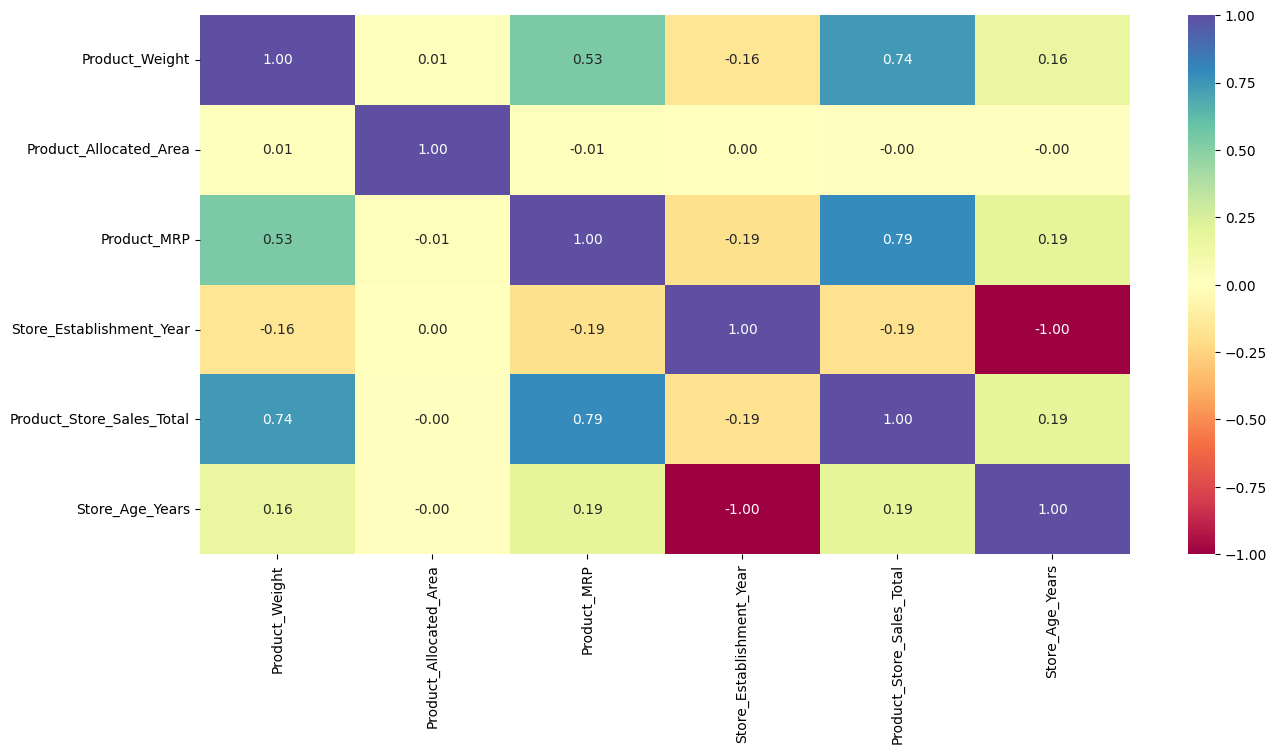

In [ ]:
# Let's check the correlation between numerical columns
plt.figure(figsize=(15, 7))
sns.heatmap(data.corr(numeric_only = True), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

- **Product MRP** has the strongest positive correlation with **Product Store Sales Total (0.788)**, indicating that higher-priced products tend to have higher sales.
- **Product Weight** also shows a strong positive correlation with **sales (0.738)**, suggesting heavier products are associated with higher sales.
- **Store Age** has a weak positive correlation with sales (0.185), while Store Establishment Year has a weak negative correlation (-0.185).
- **Product Allocated Area** has almost no correlation with sales (-0.001), indicating little linear relationship with the target.
- **Product Weight** and **MRP** are moderately correlated (0.533), suggesting some relationship between product size/weight and pricing.

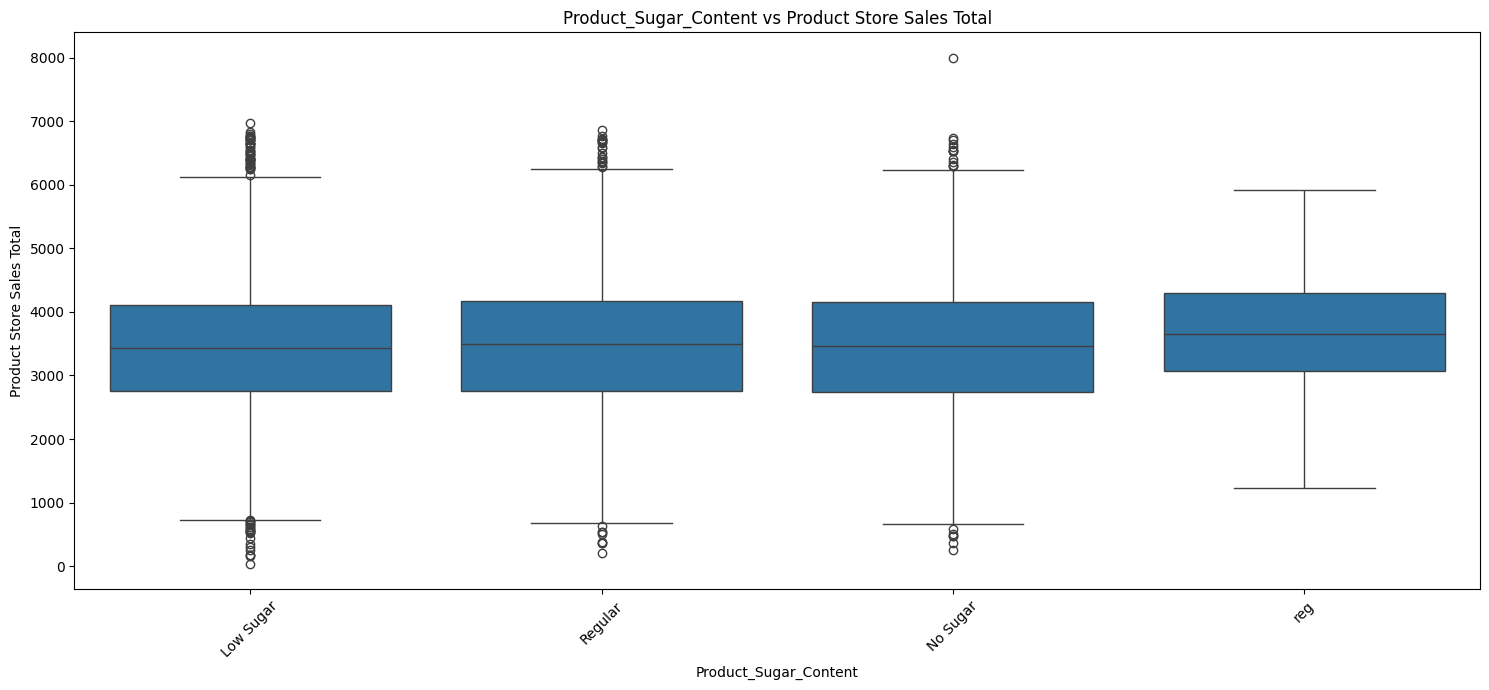

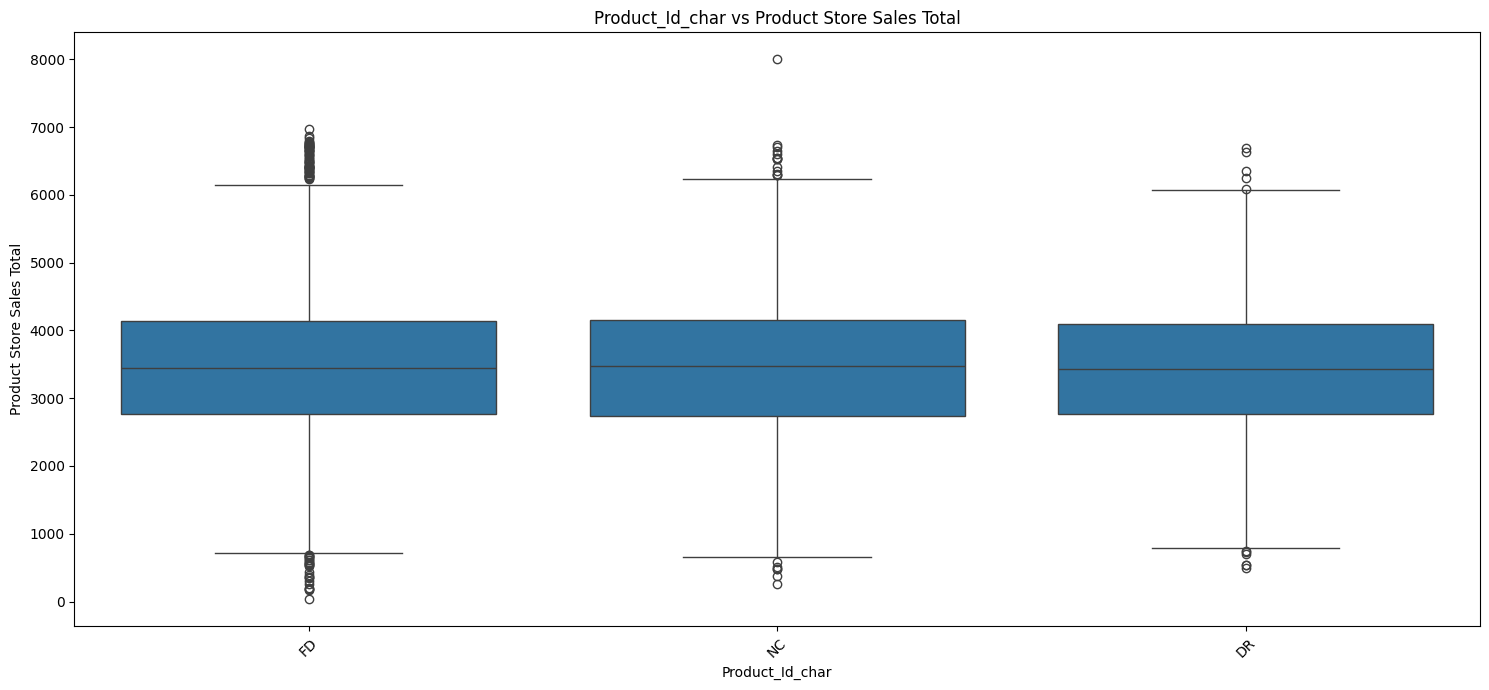

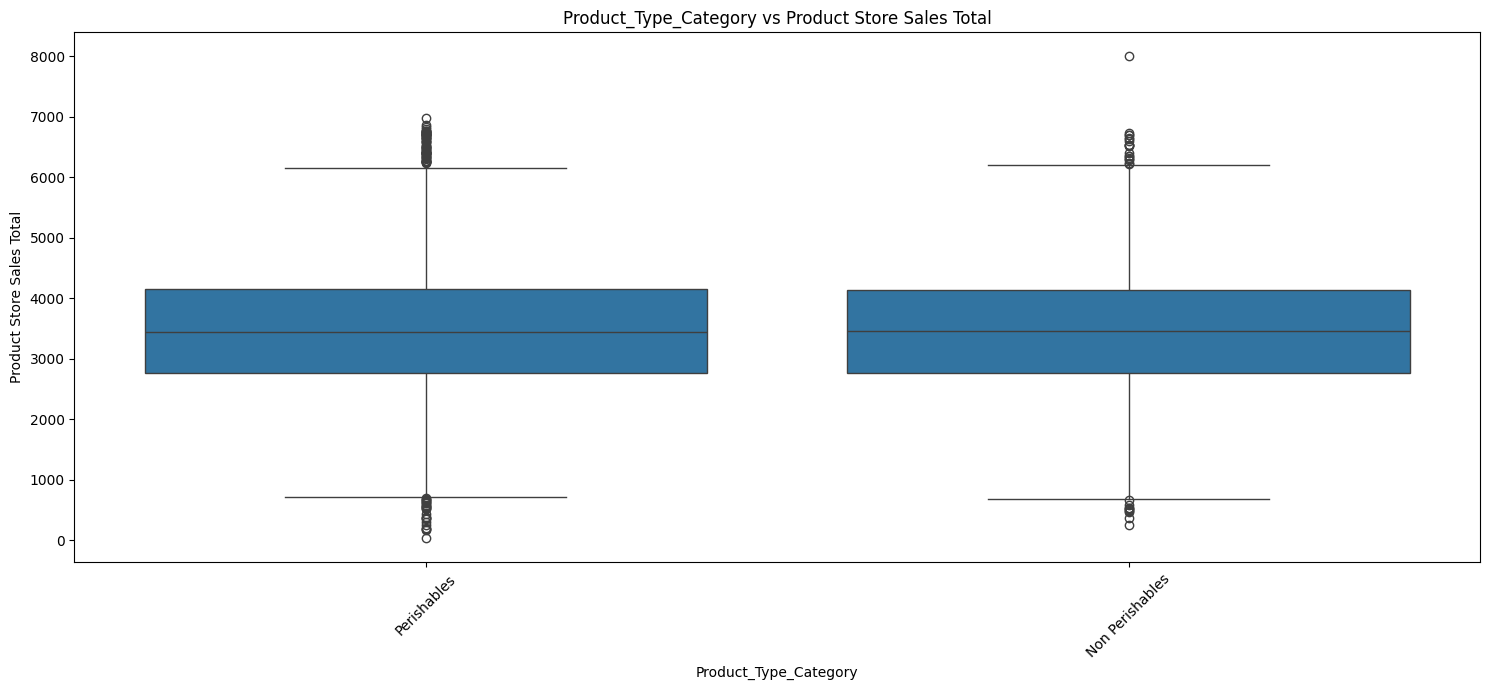

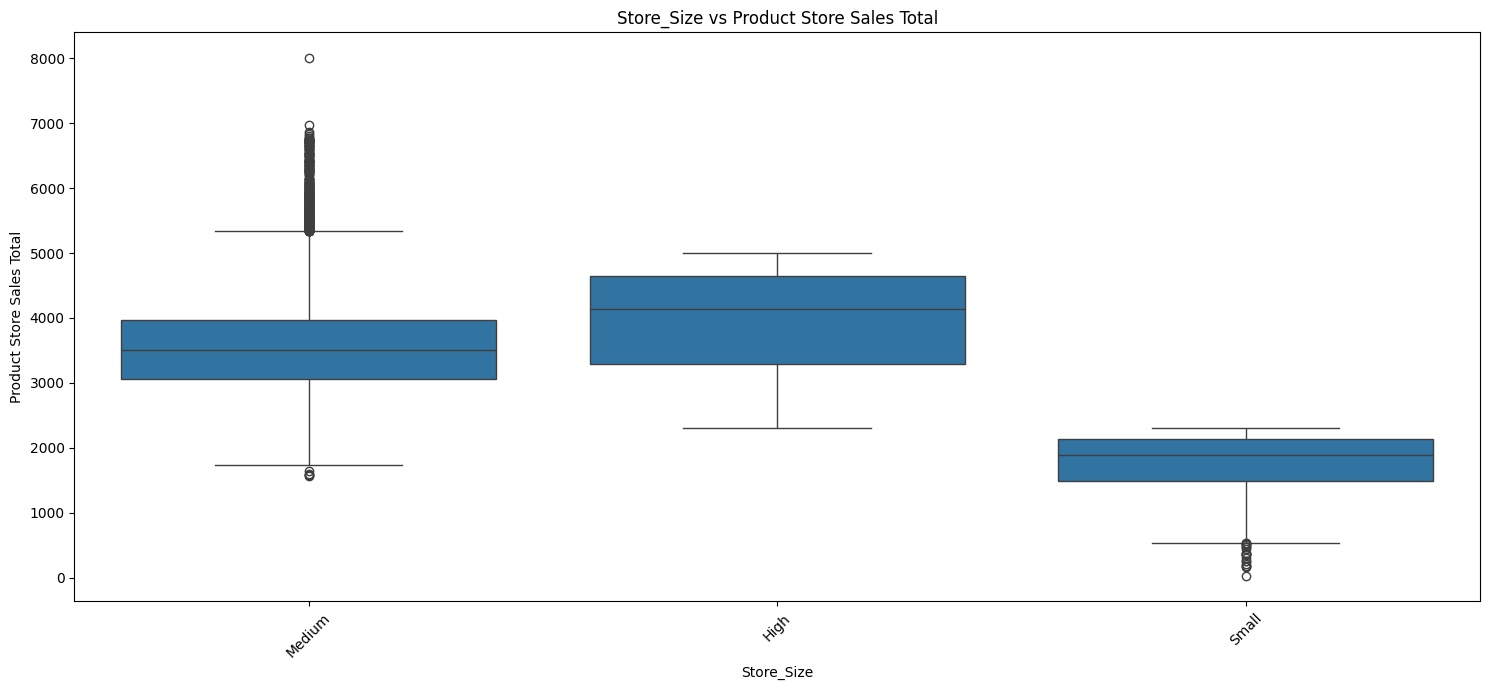

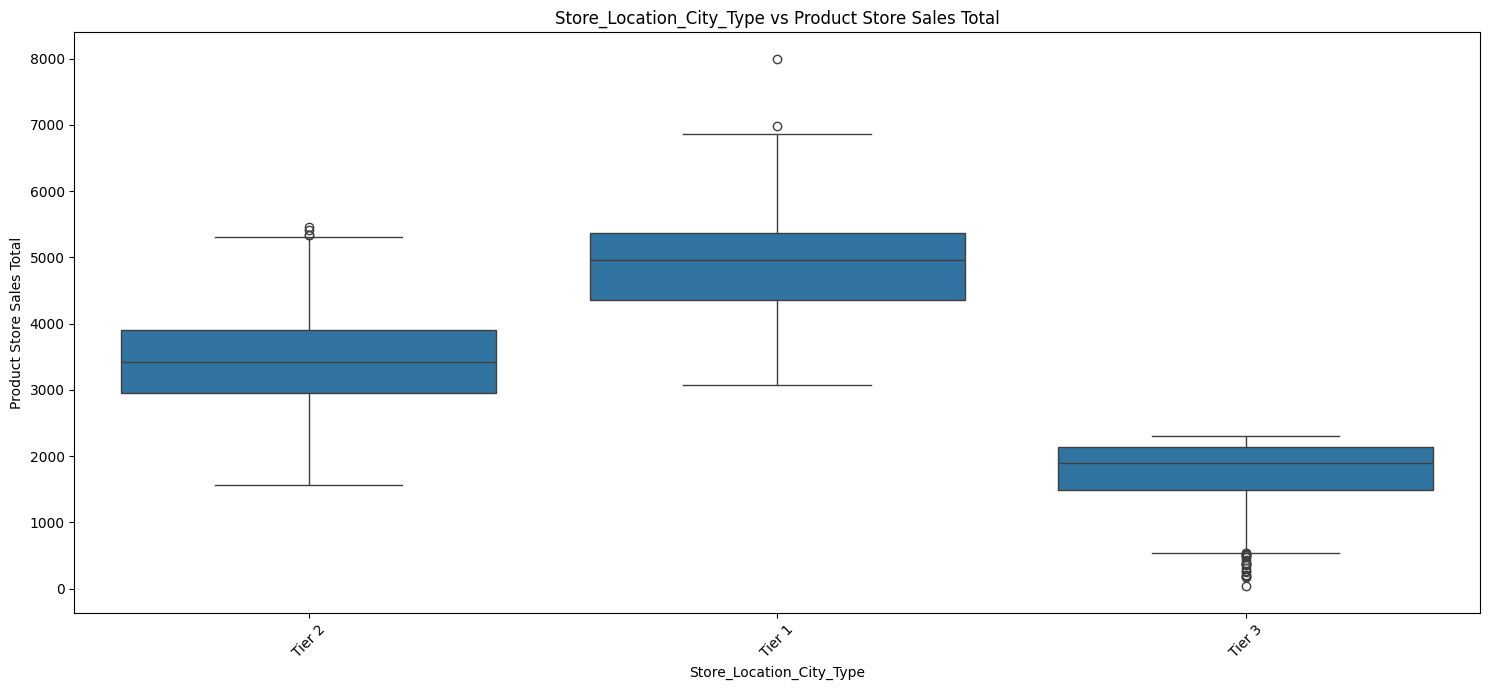

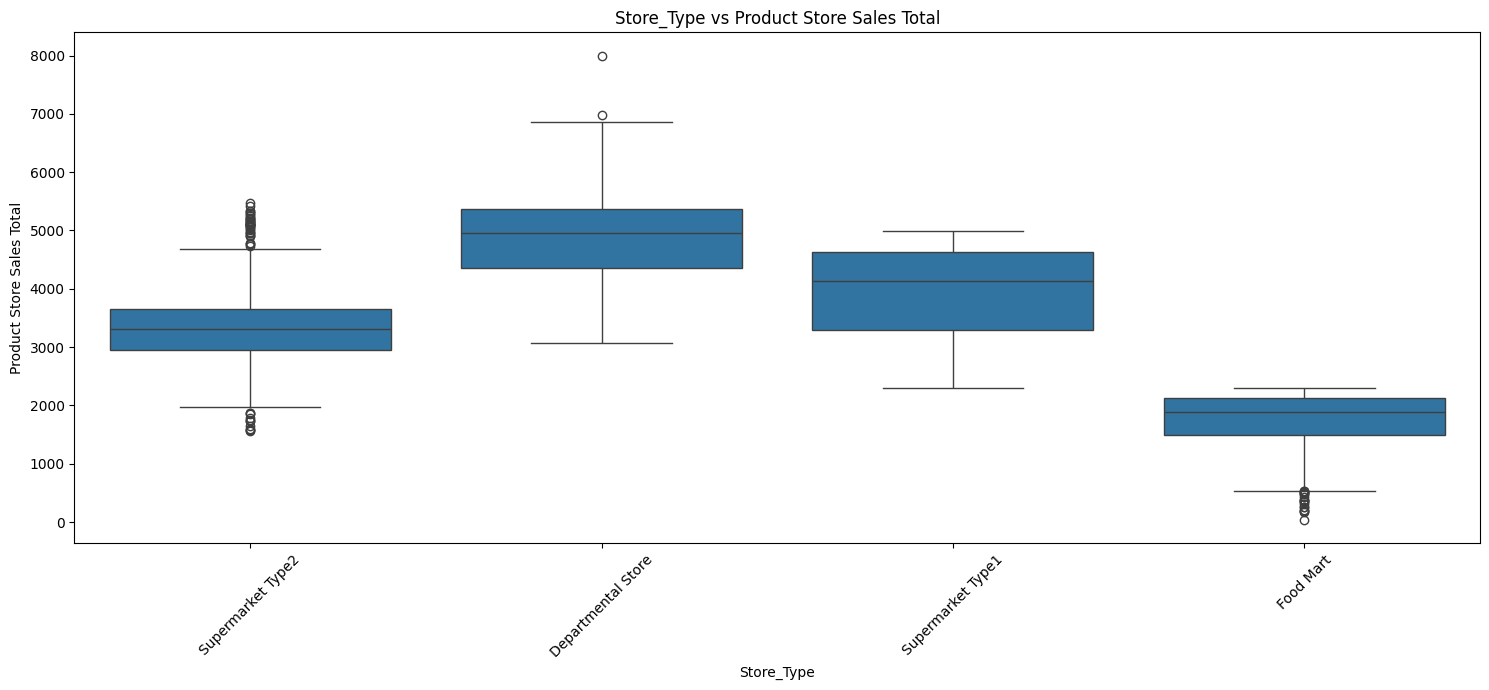

In [ ]:
for feature in categorical_features:
    plt.figure(figsize=(15, 7))

    sns.boxplot(
        x=feature,
        y='Product_Store_Sales_Total',
        data=data
    )

    plt.title(f'{feature} vs Product Store Sales Total')
    plt.xlabel(feature)
    plt.ylabel('Product Store Sales Total')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

**Observations**

**1. Store Type**

Departmental Stores have the highest median sales, followed by Supermarket Type1 and Type2.
Food Marts show the lowest median sales, indicating a strong association between store type and sales.

**2. Store Location City Type**

Tier 1 stores have the highest median sales, followed by Tier 2 and Tier 3.
Sales vary considerably across city tiers, suggesting location is an important factor.

**3. Store Size**

High-sized stores have the highest median sales, followed by Medium and Small stores.
This indicates a positive relationship between store size and sales.

**4. Product Type Category**

Perishable and Non-Perishable products have very similar median sales and distributions.
Hence, this feature shows limited differentiation in sales across categories.

**5. Product ID Character**

FD, NC, and DR categories show broadly similar median sales and distributions.
Therefore, Product ID character appears to have a weak standalone relationship with sales.

**6. Product Sugar Content**

Sales distributions across Low Sugar, Regular, and No Sugar are broadly similar.
reg shows a slightly higher median, but it represents a very small category and should be merged with Regular.

# **Data Preprocessing**

In [46]:
# Define predictor matrix (X) using selected numeric and categorical features
X = data[numeric_features + categorical_features]

# Define target variable
y = data[target]

In [14]:
data[numeric_features + categorical_features].head()

,Product_Weight,Product_Allocated_Area,Product_MRP,Store_Age_Years,Product_Sugar_Content,Product_Id_char,Product_Type_Category,Store_Size,Store_Location_City_Type,Store_Type
0,12.66,0.027,117.08,17,Low Sugar,FD,Perishables,Medium,Tier 2,Supermarket Type2
1,16.54,0.144,171.43,27,Low Sugar,FD,Perishables,Medium,Tier 1,Departmental Store
2,14.28,0.031,162.08,39,Regular,FD,Perishables,High,Tier 2,Supermarket Type1
3,12.10,0.112,186.31,39,Low Sugar,FD,Perishables,High,Tier 2,Supermarket Type1
4,9.57,0.010,123.67,28,No Sugar,NC,Non Perishables,Small,Tier 3,Food Mart


In [47]:
# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,              # Predictors (X) and target variable (y)
    test_size=0.2,     # 20% of the data is reserved for testing
    random_state=42    # Ensures reproducibility by setting a fixed random seed
)

In [48]:
# Create a preprocessing pipeline for numerical and categorical features
from sklearn.impute import SimpleImputer

preprocessor = make_column_transformer(
    (Pipeline([('num_imputer', SimpleImputer(strategy='median')),
               ('scaler', StandardScaler())]), numeric_features),
    (Pipeline([('cat_imputer', SimpleImputer(strategy='most_frequent')),
               ('encoder', OneHotEncoder(handle_unknown='ignore'))]), categorical_features)
)

# **Model Building**

## Define functions for Model Evaluation

**Utility Functions**

- We'll fit different models on the train data and observe their performance.
- We'll try to improve that performance by tuning some hyperparameters available for that algorithm.
- We'll use GridSearchCv for hyperparameter tuning and r_2 score to optimize the model.

Let's start by creating a function to get model scores, so that we don't have to use the same codes repeatedly.

In [49]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mean_absolute_percentage_error(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

The ML models to be built can be any two out of the following:
1. Decision Tree
2. Bagging
3. Random Forest
4. AdaBoost
5. Gradient Boosting
6. XGBoost

## **Random Forest Regressor - Model Training Pipeline**

In [50]:
# Define base Random Forest model
rf_model = RandomForestRegressor(random_state=42)

In [51]:
# Create pipeline with preprocessing and Random Forest model
rf_pipeline = make_pipeline(preprocessor, rf_model)

In [52]:
# Train the model pipeline on the training data
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline-1',
                                                  Pipeline(steps=[('num_imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age_Years']),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('cat_imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Product_Id_char',
                                                   'Product_Type_Category',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type'])])),
                ('randomforestregressor',
                 RandomForestRegressor(random_state=42))])

In [ ]:
#Training performance
rf_estimator_model_train_perf = model_performance_regression(rf_pipeline, X_train,y_train)
print("Training performance \n")
rf_estimator_model_train_perf

Training performance 



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,107.4914,40.236927,0.989811,0.989797,0.014921


In [ ]:
#Testing performance
rf_estimator_model_test_perf = model_performance_regression(rf_pipeline, X_test,y_test)
print("Testing performance \n")
rf_estimator_model_test_perf

Testing performance 



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,286.481584,109.599884,0.928072,0.927659,0.039282


**Observation**

- Overall performance is good with >90% R-squared

- The model is likely overfitting, as it has a higher R-squared on the train set (~ 0.9898) than on the test set (~ 0.9280). This indicates that it performs worse on unseen data.

Let's try to reduce this overfitting by tuning the hyperparameters.

## **XGBoost Regressor - Model Training Pipeline**

In [21]:
# Define base XGBoost model
xgb_model = XGBRegressor(random_state=42)

In [22]:
# Create pipeline with preprocessing and XGBoost model
xgb_pipeline = make_pipeline(preprocessor, xgb_model)

In [23]:
# Train the model pipeline on the training data
xgb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline-1',
                                                  Pipeline(steps=[('num_imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age_Years']),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('cat_imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder...
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, random_state=42, ...))])

In [ ]:
#Training performance
xgb_estimator_model_train_perf = model_performance_regression(xgb_pipeline, X_train, y_train)
print("Training performance \n")
xgb_estimator_model_train_perf

Training performance 



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,134.409301,62.537411,0.984069,0.984047,0.021832


In [ ]:
#Testing performance
xgb_estimator_model_test_perf = model_performance_regression(xgb_pipeline, X_test,y_test)
print("Testing performance \n")
xgb_estimator_model_test_perf

Testing performance 



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,315.176731,137.130241,0.912941,0.912441,0.051657


**Observation:**

There is a noticeable difference between the train and test R-squared values (~ 0.9840 vs. ~ 0.9129), suggesting that the model may be slightly overfitting.

By optimizing the model’s hyperparameters, we aim to reduce overfitting and improve performance on unseen data.

# **Model Performance Improvement - Hyperparameter Tuning**

## **Random Forest Regressor - Hyperparameter Tuning**

In [24]:
from sklearn.metrics import make_scorer, r2_score

# Choose the type of classifier.
rf_tuned = RandomForestRegressor(random_state=42)

# Create pipeline with preprocessing and XGBoost model
rf_pipeline = make_pipeline(preprocessor, rf_tuned)

# Grid of parameters to choose from
parameters = parameters = {
    'randomforestregressor__max_depth':[3, 4, 5, 6],
    'randomforestregressor__max_features': ['sqrt','log2',None],
    'randomforestregressor__n_estimators': [50, 75, 100, 125, 150]
}

# Type of scoring used to compare parameter combinations
scorer = make_scorer(r2_score)

# Run the grid search
grid_obj = GridSearchCV(rf_pipeline, parameters, scoring=scorer,cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
rf_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
rf_tuned.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline-1',
                                                  Pipeline(steps=[('num_imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age_Years']),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('cat_imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Product_Id_char',
                                                   'Product_Type_Category',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type'])])),
                ('randomforestregressor',
                 RandomForestRegressor(max_depth=6, max_features=None,
                                       n_estimators=150, random_state=42))])

In [25]:
#Training performance
rf_tuned_model_train_perf = model_performance_regression(rf_tuned, X_train, y_train)
print("Training performance \n")
rf_tuned_model_train_perf

Training performance 



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,293.574668,155.097271,0.924001,0.923892,0.055585


In [ ]:
# Testing performance
rf_tuned_model_test_perf = model_performance_regression(rf_tuned, X_test, y_test)
print("Testing performance \n")
rf_tuned_model_test_perf

Testing performance 



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,315.253913,168.148818,0.912898,0.912398,0.059327


**Observation:**

- Before tuning, there was a substantial gap between the train and test R-squared values (~ 0.9898 vs. ~ 0.9280), indicating overfitting. After tuning, this gap has decreased (~ 0.9240 vs. ~ 0.9128), suggesting that the model is now generalizing better to unseen data.

- The R-squared on the test set has decreased from ~ 0.9294 to ~ 0.9123 after hyperparameter tuning, but its fairly good indicates that the tuned model is good enough at predicting the target variable on new, unseen data.

## **XGBoost Regressor - Hyperparameter Tuning**

In [26]:
from sklearn.metrics import make_scorer, r2_score

# Choose the type of classifier.
xgb_tuned = XGBRegressor(random_state=42)

# Create pipeline with preprocessing and XGBoost model
xgb_pipeline = make_pipeline(preprocessor, xgb_tuned)

#Grid of parameters to choose from
param_grid = {
    'xgbregressor__n_estimators': [50, 100, 150, 200],    # number of trees to build
    'xgbregressor__max_depth': [2, 3, 4],    # maximum depth of each tree
    'xgbregressor__colsample_bytree': [0.4, 0.5, 0.6],    # percentage of attributes to be considered (randomly) for each tree
    'xgbregressor__colsample_bylevel': [0.4, 0.5, 0.6],    # percentage of attributes to be considered (randomly) for each level of a tree
    'xgbregressor__learning_rate': [0.01, 0.05, 0.1],    # learning rate
    'xgbregressor__reg_lambda': [0.4, 0.5, 0.6],    # L2 regularization factor
}

# Type of scoring used to compare parameter combinations
scorer = make_scorer(r2_score)

# Run the grid search
grid_obj = GridSearchCV(xgb_pipeline, param_grid, scoring=scorer,cv=5,n_jobs=-1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
xgb_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
xgb_tuned.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline-1',
                                                  Pipeline(steps=[('num_imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age_Years']),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('cat_imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder...
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=4, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=200, n_jobs=None,
                              num_parallel_tree=None, random_state=42, ...))])

In [ ]:
# Training performance
xgb_tuned_model_train_perf = model_performance_regression(xgb_tuned, X_train, y_train)
print("Training performance \n")
xgb_tuned_model_train_perf

Training performance 



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,268.24647,114.767263,0.936549,0.936458,0.045343


In [ ]:
#Testing performance
xgb_tuned_model_test_perf = model_performance_regression(xgb_tuned, X_test, y_test)
print("Testing performance \n")
xgb_tuned_model_test_perf

Testing performance 



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,299.743502,131.341483,0.921258,0.920806,0.049358


**Observation:**

- The gap between training and testing R-squared has decreased (0.9365 vs 0.9212), indicating better generalization after hyperparameter tuning.

- Testing R-squared increased slightly (from 0.9129 to 0.9212), suggesting marginally better predictions on new data after tuning.

# **Model Performance Comparison, Final Model Selection, and Serialization**

In [ ]:
# training performance comparison

models_train_comp_df = pd.concat(
    [rf_estimator_model_train_perf.T,rf_tuned_model_train_perf.T,
    xgb_estimator_model_train_perf.T,xgb_tuned_model_train_perf.T],
    axis=1,
)

models_train_comp_df.columns = [
    "Random Forest Estimator",
    "Random Forest Tuned",
    "XGBoost",
    "XGBoost Tuned"
]

print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Random Forest Estimator,Random Forest Tuned,XGBoost,XGBoost Tuned
RMSE,107.491400,293.574668,134.409301,268.246470
MAE,40.236927,155.097271,62.537411,114.767263
R-squared,0.989811,0.924001,0.984069,0.936549
Adj. R-squared,0.989797,0.923892,0.984047,0.936458
MAPE,0.014921,0.055585,0.021832,0.045343


In [ ]:
# Testing performance comparison

models_test_comp_df = pd.concat(
    [rf_estimator_model_test_perf.T,rf_tuned_model_test_perf.T,
    xgb_estimator_model_test_perf.T,xgb_tuned_model_test_perf.T],
    axis=1,
)

models_test_comp_df.columns = [
    "Random Forest Estimator",
    "Random Forest Tuned",
    "XGBoost",
    "XGBoost Tuned"
]

print("Testing performance comparison:")
models_test_comp_df

Testing performance comparison:


,Random Forest Estimator,Random Forest Tuned,XGBoost,XGBoost Tuned
RMSE,286.481584,315.253913,315.176731,299.743502
MAE,109.599884,168.148818,137.130241,131.341483
R-squared,0.928072,0.912898,0.912941,0.921258
Adj. R-squared,0.927659,0.912398,0.912441,0.920806
MAPE,0.039282,0.059327,0.051657,0.049358


In [ ]:
(models_train_comp_df - models_test_comp_df).iloc[2]

,R-squared
Random Forest Estimator,0.061740
Random Forest Tuned,0.011103
XGBoost,0.071129
XGBoost Tuned,0.015291


In [ ]:
r2_comparison = pd.DataFrame({
    'Train R²': models_train_comp_df.iloc[2],
    'Test R²': models_test_comp_df.iloc[2],
    'Difference': (models_train_comp_df - models_test_comp_df).iloc[2]
})

r2_comparison

,Train R²,Test R²,Difference
Random Forest Estimator,0.989811,0.928072,0.061740
Random Forest Tuned,0.924001,0.912898,0.011103
XGBoost,0.984069,0.912941,0.071129
XGBoost Tuned,0.936549,0.921258,0.015291


**Observations:**

- The Random Forest model has the highest R² score on the test set.

- We should also consider the difference between the train and test R² scores. In this regard, the tuned Random Forest model shows the smallest difference, followed by the tuned XGBoost model.

- However, when comparing the train scores of the Random Forest model and Tuned Random Forest model, the R² score of the Random Forest model is higher.

- Based on all these observations, the **Random Forest model** can be considered the best overall.

# **Model Serialization**

Note: Based on the model comparison, the Random Forest model demonstrated the best performance on the testing data. Therefore, we will serialize this model for deployment.

In [53]:
# Create a folder for storing the files needed for web app deployment
os.makedirs("deployment_files", exist_ok=True)

In [59]:
# Define the file path to save (serialize) the trained model along with the data preprocessing steps
saved_model_path = "/content/deployment_files/superkart_model_v1.joblib"

In [60]:
# Save the best trained model pipeline using joblib
joblib.dump(rf_pipeline, saved_model_path,compress=3)

print(f"Model saved successfully at {saved_model_path}")

Model saved successfully at /content/deployment_files/superkart_model_v1.joblib


In [33]:
# Load the saved model pipeline from the file
saved_model = joblib.load("deployment_files/superkart_model_v1_0.joblib")

# Confirm the model is loaded
print("Model loaded successfully.")

Model loaded successfully.


In [34]:
saved_model

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline-1',
                                                  Pipeline(steps=[('num_imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age_Years']),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('cat_imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Product_Id_char',
                                                   'Product_Type_Category',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type'])])),
                ('randomforestregressor',
                 RandomForestRegressor(random_state=42))])

Let's try making predictions on the test set using the deserialized model.


In [35]:
saved_model.predict(X_test)

array([3417.3692, 3367.0166, 2420.0388, ..., 4160.1062, 2816.5813,
       4511.357 ])

- As we can see, the model can be directly used for making predictions without any retraining.

In [38]:
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Id_char,Product_Category,Product_Type_Category,Store_Age_Years
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40,FD,Food,Perishables,17
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02,FD,Food,Perishables,27
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16,FD,Food,Perishables,39
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18,FD,Food,Perishables,39
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36,NC,Non-Food,Non Perishables,28


In [39]:
# Load the data:
superkart_batch_data = pd.read_csv("/content/ModelDeployment/Batch_Data_SuperKart.csv")

In [40]:
superkart_batch_data

,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_MRP,Store_Size,Store_Location_City_Type,Store_Type,Product_Id_char,Store_Age_Years,Product_Type_Category
0,12.66,Low Sugar,0.027,117.08,Small,Tier 1,Supermarket Type1,FD,16,Perishables
1,8.20,Regular,0.045,85.50,Medium,Tier 2,Supermarket Type2,DR,22,Non Perishables
2,15.40,No Sugar,0.012,210.75,High,Tier 3,Departmental Store,NC,8,Non Perishables
3,5.75,Regular,0.060,55.20,Small,Tier 1,Food Mart,FD,30,Perishables
4,19.30,Low Sugar,0.033,145.60,Medium,Tier 2,Supermarket Type3,DR,12,Non Perishables
5,10.00,No Sugar,0.050,92.40,High,Tier 1,Supermarket Type1,NC,5,Non Perishables
6,7.85,Regular,0.018,178.90,Small,Tier 3,Supermarket Type2,FD,19,Perishables
7,14.10,Low Sugar,0.041,63.25,Medium,Tier 2,Food Mart,DR,27,Perishables
8,3.50,No Sugar,0.009,250.00,High,Tier 1,Departmental Store,NC,10,Non Perishables
9,11.25,Regular,0.055,130.45,Small,Tier 3,Supermarket Type3,FD,14,Perishables


In [41]:
# Make predictions (fet sales)

# Create a copy to avoid modifying the original batch data directly if it's used elsewhere
processed_batch_data = superkart_batch_data.copy()


# Define the list of expected features based on the training data
expected_features = numeric_features + categorical_features

# Select only the expected features in the correct order
batch_data_final = processed_batch_data[expected_features]

predictions_sale = saved_model.predict(batch_data_final)

In [42]:
# Display predictions:
print(predictions_sale)

[4232.3495 2932.3877 3929.4953 1934.1287 4098.5764 5154.8729 2503.0232
 2389.1968 4598.4236 2505.7719]


- As we can see, the model can be directly used for making predictions without any retraining.

# **Deployment - Backend**

## Points to note before executing the below cells
- Create a GitHub account if you don't already have one at [github.com](https://github.com)
- Generate a **Personal Access Token**
  - Make sure the token has **repo** scope (full control of private repositories)
- The serialized ML model file (`superkart_model.joblib`) should already be present in the `backend_files` folder before pushing to GitHub
- We will deploy **both the Flask backend and the Streamlit frontend as separate Docker containers** inside a GitHub Codespace, and connect them using a **Docker network**

## Flask Web Framework

Flask is a lightweight, flexible Python web framework used to build web applications and APIs quickly and easily.

Flask allows you to:
- Create web routes (URLs that users can access)
- Handle HTTP requests and responses
- Build REST APIs to expose machine learning models or other services

In [1]:
import os

# Create a folder to upload your trained serialized model into it
os.makedirs("backend_files", exist_ok=True)

In [26]:
%%writefile backend_files/app.py
# Import necessary libraries
import numpy as np
import joblib  # For loading the serialized model
import pandas as pd  # For data manipulation
from flask import Flask, request, jsonify  # For creating the Flask API

# Initialize the Flask application
superkart_sale_predictor_api = Flask("Superkart Sale Predictor")

# Load the trained machine learning model
model = joblib.load("superkart_model_v1.joblib")

# Define a route for the home page (GET request)
@superkart_sale_predictor_api.get('/')
def home():
    """
    This function handles GET requests to the root URL ('/') of the API.
    It returns a simple welcome message.
    """
    return "Welcome to the Superkart Sale Prediction API!"

# Define an endpoint for single product sale (POST request)
@superkart_sale_predictor_api.post('/v1/superkart')
def predict_superkart_sale():
    """
    This function handles POST requests to the '/v1/superkart' endpoint.
    It expects a JSON payload containing property details and returns
    the predicted sale as a JSON response.
    """
    # Get the JSON data from the request body
    product_data = request.get_json()

    # Extract relevant features from the JSON data
    sample = {
        'Product_Weight': product_data['Product_Weight'],
        'Product_Sugar_Content': product_data['Product_Sugar_Content'],
        'Product_Allocated_Area': product_data['Product_Allocated_Area'],
        'Product_MRP': product_data['Product_MRP'],
        'Store_Size': product_data['Store_Size'],
        'Store_Location_City_Type': product_data['Store_Location_City_Type'],
        'Store_Type': product_data['Store_Type'],
        'Product_Id_char': product_data['Product_Id_char'],
        'Store_Age_Years': product_data['Store_Age_Years'],
        'Product_Type_Category': product_data['Product_Type_Category']
    }

    # Convert the extracted data into a Pandas DataFrame
    input_data = pd.DataFrame([sample])

    # Make prediction (get sale volume)
    predicted_sale = model.predict(input_data)[0]

    # Convert predicted_sale to Python float
    predicted_sale = round(float(predicted_sale), 2)

    # Return the actual price
    return jsonify({'Predicted Sale (in dollars)': predicted_sale})


# Define an endpoint for batch prediction (POST request)
@superkart_sale_predictor_api.post('/v1/superkartbatch')
def predict_superkart_sale_batch():
    """
    This function handles POST requests to the '/v1/superkartbatch' endpoint.
    It expects a CSV file containing product and store details for multiple products
    and returns the predicted sale as a dictionary in the JSON response.
    """
    # Get the uploaded CSV file from the request
    file = request.files['file']

    # Read the CSV file into a Pandas DataFrame
    input_data = pd.read_csv(file)

    # Make predictions
    predicted_sales = model.predict(input_data)

    # Add prediction as a new column
    input_data['Predicted_Sales'] = predicted_sales

    # Convert complete DataFrame to JSON
    output_dict = input_data.to_dict(orient='records')

    return output_dict


# Run the Flask application in debug mode if this script is executed directly
if __name__ == '__main__':
    # superkart_sale_predictor_api.run(debug=True)
    superkart_sale_predictor_api.run(
        host="0.0.0.0",
        port=7860,
        debug=True
    )

Overwriting backend_files/app.py


## Dependencies File

In [23]:
%%writefile backend_files/requirements.txt
numpy==2.1.3
pandas==2.2.3
scikit-learn==1.6.1
xgboost==2.1.4
joblib==1.6.0
Werkzeug==2.2.2
flask==2.2.2
streamlit==1.43.2
gunicorn==20.1.0
requests==2.28.1
uvicorn[standard]


Overwriting backend_files/requirements.txt


## Dockerfile

In [17]:
%%writefile backend_files/Dockerfile
FROM python:3.11-slim

# Set the working directory inside the container
WORKDIR /app

# Copy all files from the current directory to the container's working directory
COPY . .

# Install dependencies from the requirements file without using cache to reduce image size
RUN pip install --no-cache-dir --upgrade -r requirements.txt

# Define the command to start the application using Gunicorn with 4 worker processes
# - `-w 4`: Uses 4 worker processes for handling requests
# - `-b 0.0.0.0:7860`: Binds the server to port 7860 on all network interfaces
# - `app:app`: Runs the Flask app (assuming `app.py` contains the Flask instance named `app`)
CMD ["gunicorn", "-w", "4", "-b", "0.0.0.0:7860", "app:superkart_sale_predictor_api"]

Overwriting backend_files/Dockerfile


In [46]:
# copying serialized ML model (superkart_model_v1.joblib) to folder backend_files
!cp /content/deployment_files/superkart_model_v1.joblib /content/backend_files/

# **Deployment - Frontend**

- The frontend Streamlit app will communicate with the backend Flask API **over a Docker network**
- Instead of calling a public URL, the Streamlit app will call `http://backend:7860` - here `backend` is the **container name** we will assign when running the Docker container, and Docker's internal DNS resolves it automatically
- Both containers will be launched inside the same GitHub Codespace

## Streamlit for Interactive UI

In [5]:
# Create a folder for storing the files needed for frontend UI deployment
os.makedirs("frontend_files", exist_ok=True)

In [29]:
%%writefile frontend_files/app.py
import streamlit as st
import pandas as pd
import requests

# Base URL of the Flask backend
# BACKEND_URL = "http://backend:7860"
BACKEND_URL = "http://localhost:7860"

# Set the title of the Streamlit app
st.title("Superkart Sale Prediction")

# Section for online prediction
st.subheader("Online Prediction")

# store_age_mapping = {
#     "Supermarket Type1": 39,
#     "Food Mart": 28,
#     "Departmental Store": 27,
#     "Supermarket Type2": 17
# }
# # Automatically derive Store Age
# Store_Age_Years = store_age_mapping[Store_Type]
# # Display derived value but don't allow user to change it
# st.number_input( "Store Age (Years)", value=Store_Age_Years, disabled=True)


# Collect user input for property features
Product_Weight = st.number_input("Product Weight", min_value=0.0, value=100.0)
Product_Sugar_Content = st.selectbox("Product Sugar Content", ["Regular", "Low Sugar", "No Sugar"])
Product_Allocated_Area = st.number_input("Product Allocated Area", min_value=0.0, value=100.0)
Product_MRP = st.number_input("Product MRP", min_value=0.0, value=1000.0)
Store_Size = st.selectbox("Store Size", ["High", "Medium", "Small"])
Store_Location_City_Type = st.selectbox("Store Location City Type", ["Tier 1", "Tier 2", "Tier 3"])
Store_Type = st.selectbox("Store Type", ["Supermarket Type1", "Supermarket Type2", "Departmental Store","Food Mart"])
Product_Id_char = st.selectbox("Product_Id_char (First 2 Charecter of Product_ID)", ["FD", "NC", "DR"])
Store_Age_Years = st.number_input( "Store Age (Years)", min_value=0, value=100)
Product_Type_Category = st.selectbox("Product Type Category", ["Perishables", "Non Perishables"])

# Convert user input into a DataFrame
input_data = pd.DataFrame({
    "Product_Weight": [Product_Weight],
    "Product_Sugar_Content": [Product_Sugar_Content],
    "Product_Allocated_Area": [Product_Allocated_Area],
    "Product_MRP": [Product_MRP],
    "Store_Size": [Store_Size],
    "Store_Location_City_Type": [Store_Location_City_Type],
    "Store_Type": [Store_Type],
    "Product_Id_char": [Product_Id_char],
    "Store_Age_Years": [Store_Age_Years],
    "Product_Type_Category": [Product_Type_Category]
})

# Make prediction when the "Predict" button is clicked
if st.button("Predict", type="primary"):
    response = requests.post(f"{BACKEND_URL}/v1/superkart", json=input_data.to_dict(orient='records')[0])  # Send data to Flask API
    if response.status_code == 200:
        prediction = response.json()['Predicted Sale (in dollars)']
        st.success(f"Predicted Sale (in dollars): {prediction}")
    else:
        st.error("Unable to connect to the prediction API.")

# Section for batch prediction
st.subheader("Batch Prediction")

# Allow users to upload a CSV file for batch prediction
uploaded_file = st.file_uploader("Upload CSV file for batch prediction", type=["csv"])

# Make batch prediction when the "Predict Batch" button is clicked
if uploaded_file is not None:
    if st.button("Predict Batch", type="primary"):
        response = requests.post(f"{BACKEND_URL}/v1/superkartbatch", files={"file": uploaded_file})  # Send file to Flask API
        if response.status_code == 200:
            predictions = response.json()
            st.success("Batch predictions completed!")
            st.write(predictions)  # Display the predictions
        else:
            st.error("Unable to connect to the prediction API.")

Overwriting frontend_files/app.py


## Dependencies File

In [7]:
%%writefile frontend_files/requirements.txt
pandas==2.2.3
streamlit==1.43.2
requests==2.28.1


Overwriting frontend_files/requirements.txt


## Dockerfile

In [18]:
%%writefile frontend_files/Dockerfile
# Use a minimal base image with Python 3.9 installed
FROM python:3.11-slim

# Set the working directory inside the container to /app
WORKDIR /app

# Copy all files from the current directory on the host to the container's /app directory
COPY . .

# Install Python dependencies listed in requirements.txt
RUN pip3 install -r requirements.txt

# Define the command to run the Streamlit app on port 8501 and make it accessible externally
CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false"]

# NOTE: Disable XSRF protection for easier external access in order to make batch predictions

Overwriting frontend_files/Dockerfile


# **Pushing Deployment Files to GitHub**


1. **Define authentication and repository details:**
   - `GITHUB_TOKEN` stores the GitHub Personal Access Token for authentication.
   - `REPO_NAME` specifies the name of the new GitHub repository.

2. **Authenticate with GitHub:**
   - `g = Github(GITHUB_TOKEN)` creates a GitHub client using the token.
   - `user = g.get_user()` retrieves the authenticated user.

3. **Create the repository:**
   - `user.create_repo()` creates a new public repository on GitHub with an auto-generated README.

4. **Push files to the repository:**
   - `repo.create_file()` uploads each deployment file to the repository.
   - Backend files (`app.py`, `requirements.txt`, `Dockerfile`, model) go into the `backend/` folder.
   - Frontend files (`app.py`, `requirements.txt`, `Dockerfile`) go into the `frontend/` folder.
   - For the `.joblib` model file, which is binary, PyGithub handles the encoding automatically.


## Setting Up a GitHub Repository

The code below authenticates with GitHub account using the Personal Access Token, creates a new public repository, and pushes all the backend and frontend files to it.

The files are pushed with a folder structure that keeps backend and frontend separate:

```
repo root/
    backend/
        app.py
        requirements.txt
        Dockerfile
        superkart_model_v1.joblib
    frontend/
        app.py
        requirements.txt
        Dockerfile
```

This folder structure is important because when we open a Codespace from this repo, we will `cd` into each folder separately to build its Docker image.

In [14]:
# Your GitHub Personal Access Token

from google.colab import userdata
GITHUB_TOKEN = userdata.get('Github')

g = Github(GITHUB_TOKEN)
user = g.get_user()

print(f"Authenticated as: {user.login}")

Authenticated as: preetipss


In [21]:
from github import Github
from github.GithubException import UnknownObjectException

# -----------------------------
# Create NEW repository
# -----------------------------
REPO_NAME = "superkart-sale-prediction-rest-api"

repo = user.create_repo(
    REPO_NAME,
    description="SuperKart Sale Prediction - Flask API Backend + Streamlit Frontend",
    private=False,
    auto_init=True
)

print(f"Repository created successfully: {repo.html_url}")


# -----------------------------
# Files to upload
# -----------------------------
files_to_push = {
    "backend/app.py": "backend_files/app.py",
    "backend/requirements.txt": "backend_files/requirements.txt",
    "backend/Dockerfile": "backend_files/Dockerfile",
    "backend/superkart_model_v1.joblib":
        "backend_files/superkart_model_v1.joblib",

    "frontend/app.py": "frontend_files/app.py",
    "frontend/requirements.txt": "frontend_files/requirements.txt",
    "frontend/Dockerfile": "frontend_files/Dockerfile",
}


# -----------------------------
# Upload files
# -----------------------------
for repo_path, local_path in files_to_push.items():

    with open(local_path, "rb") as f:
        content = f.read()

    repo.create_file(
        path=repo_path,
        message=f"Add {repo_path}",
        content=content,
        branch="main"
    )

    print(f"Uploaded: {repo_path}")


print(f"\nAll files pushed successfully to: {repo.html_url}")

Repository created successfully: https://github.com/preetipss/superkart-sale-prediction-rest-api
Uploaded: backend/app.py
Uploaded: backend/requirements.txt
Uploaded: backend/Dockerfile
Uploaded: backend/superkart_model_v1.joblib
Uploaded: frontend/app.py
Uploaded: frontend/requirements.txt
Uploaded: frontend/Dockerfile

All files pushed successfully to: https://github.com/preetipss/superkart-sale-prediction-rest-api


In [30]:
from github import Github
from github.GithubException import UnknownObjectException

# -----------------------------
# Get existing repository
# -----------------------------
REPO_NAME = "superkart-sale-prediction-rest-api"

repo = user.get_repo(REPO_NAME)

print(f"Using existing repository: {repo.html_url}")


# -----------------------------
# Files to upload / update
# -----------------------------
files_to_push = {
    "backend/app.py": "backend_files/app.py",
    "backend/requirements.txt": "backend_files/requirements.txt",
    "backend/Dockerfile": "backend_files/Dockerfile",
    "backend/superkart_model_v1.joblib":"backend_files/superkart_model_v1.joblib",

    "frontend/app.py": "frontend_files/app.py",
    "frontend/requirements.txt": "frontend_files/requirements.txt",
    "frontend/Dockerfile": "frontend_files/Dockerfile",
}


# -----------------------------
# Upload / Overwrite files
# -----------------------------
for repo_path, local_path in files_to_push.items():

    with open(local_path, "rb") as f:
        content = f.read()

    try:
        # Try to find the file in GitHub
        existing_file = repo.get_contents(
            repo_path,
            ref="main"
        )

        # File exists → overwrite it
        repo.update_file(
            path=repo_path,
            message=f"Update {repo_path}",
            content=content,
            sha=existing_file.sha,
            branch="main"
        )

        print(f"Updated: {repo_path}")

    except UnknownObjectException:

        # File does not exist → create it
        repo.create_file(
            path=repo_path,
            message=f"Add {repo_path}",
            content=content,
            branch="main"
        )

        print(f"Uploaded: {repo_path}")


print(f"\nAll files pushed successfully to: {repo.html_url}")

Using existing repository: https://github.com/preetipss/superkart-sale-prediction-rest-api
Updated: backend/app.py
Updated: backend/requirements.txt
Updated: backend/Dockerfile
Updated: backend/superkart_model_v1.joblib
Updated: frontend/app.py
Updated: frontend/requirements.txt
Updated: frontend/Dockerfile

All files pushed successfully to: https://github.com/preetipss/superkart-sale-prediction-rest-api


In [16]:
import os

model_path = "backend_files/superkart_model_v1.joblib"

size_mb = os.path.getsize(model_path) / (1024 * 1024)

print(f"Model size: {size_mb:.2f} MB")

Model size: 13.76 MB


# **Screenshots of Deployment and Final App Predictions**

In [ ]:
#Links:

# Links:
Frondend : https://probable-space-train-g49jrj9xgp44c9597-8501.app.github.dev/

Backend : https://probable-space-train-g49jrj9xgp44c9597-7860.app.github.dev/

In [29]:
# Create a folder for storing the files needed for web app deployment
os.makedirs("screenshots", exist_ok=True)

In [ ]:
from IPython.display import Image, display

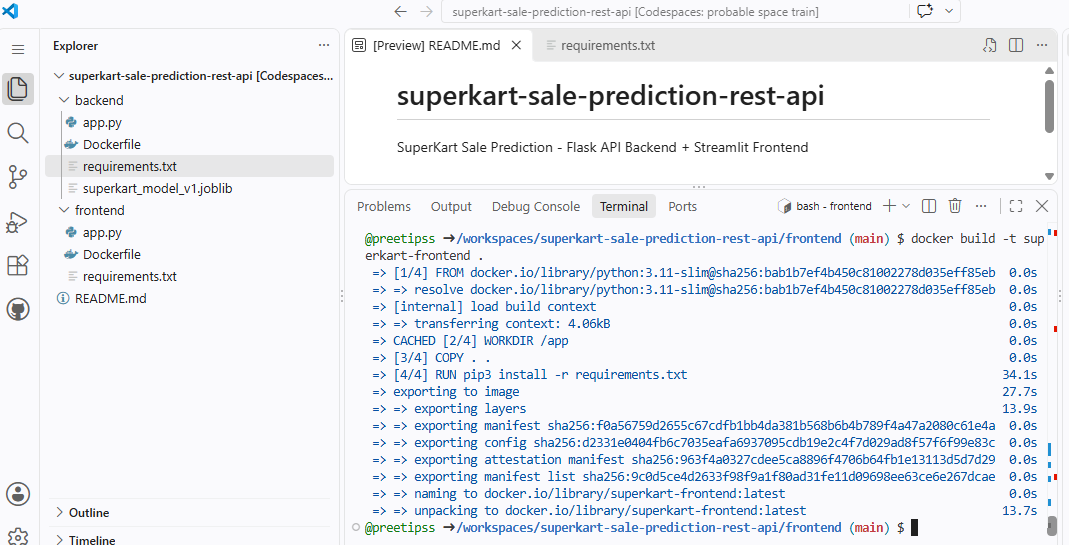

In [30]:
#Frontend Deployment
display(Image(filename="/content/screenshots/Frontend.png", width=1000))

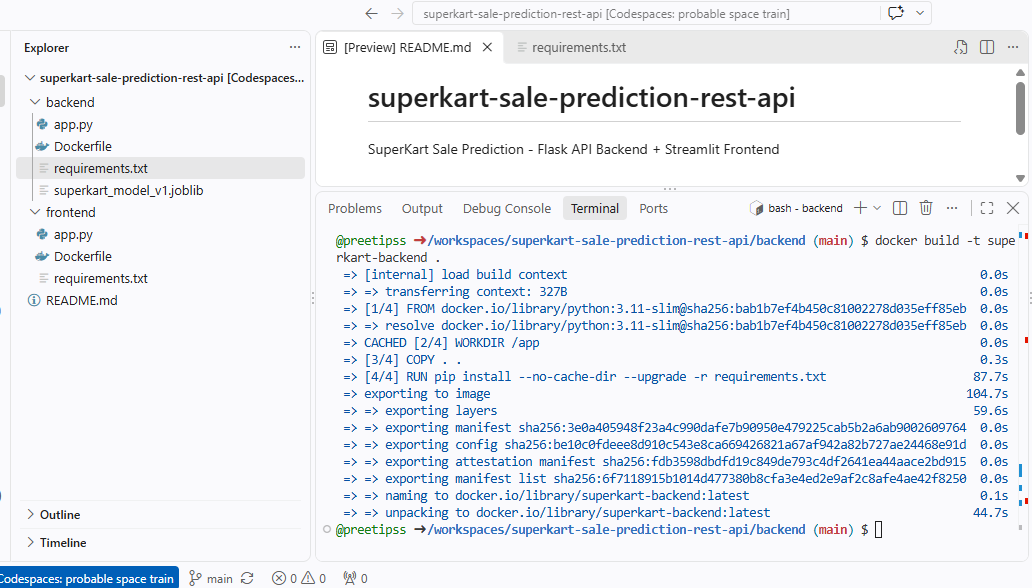

In [31]:
#Backend Deployment
display(Image(filename="/content/screenshots/Backend.png", width=1000))

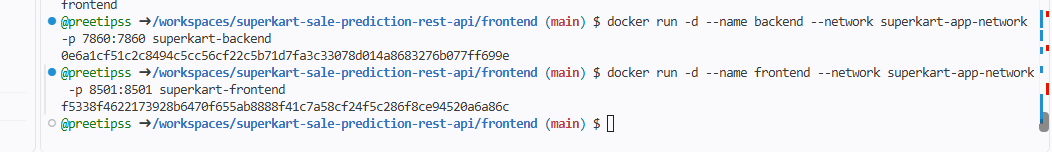

In [32]:
#Containsers creation
display(Image(filename="/content/screenshots/Containsers_creation.png", width=1000))

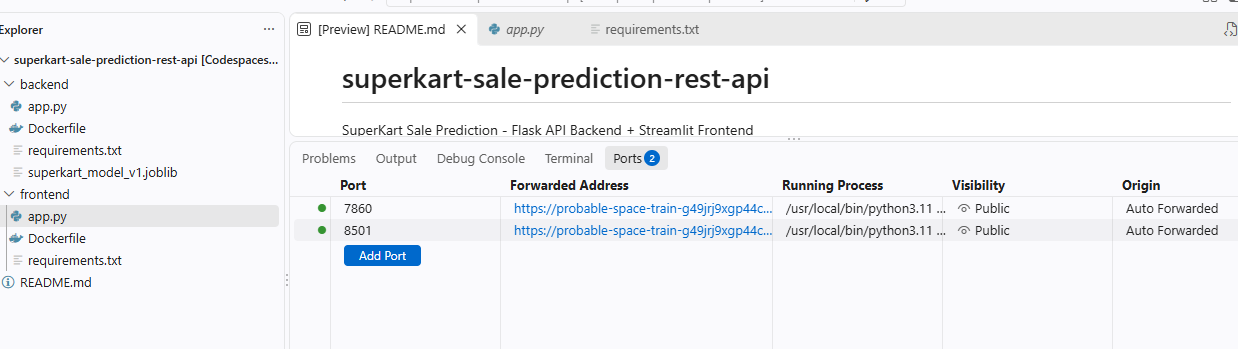

In [33]:
#Ports
display(Image(filename="/content/screenshots/Ports.png", width=1000))

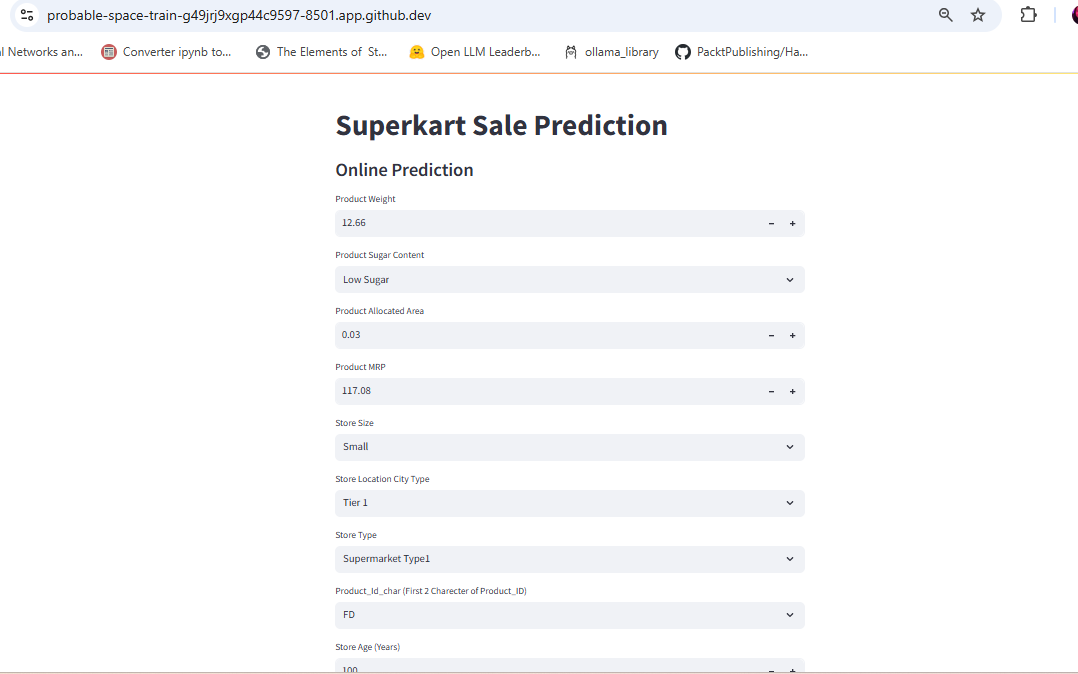

In [34]:
#App Single Prediction 1st
display(Image(filename="/content/screenshots/App Single Prediction_1.png", width=1000))

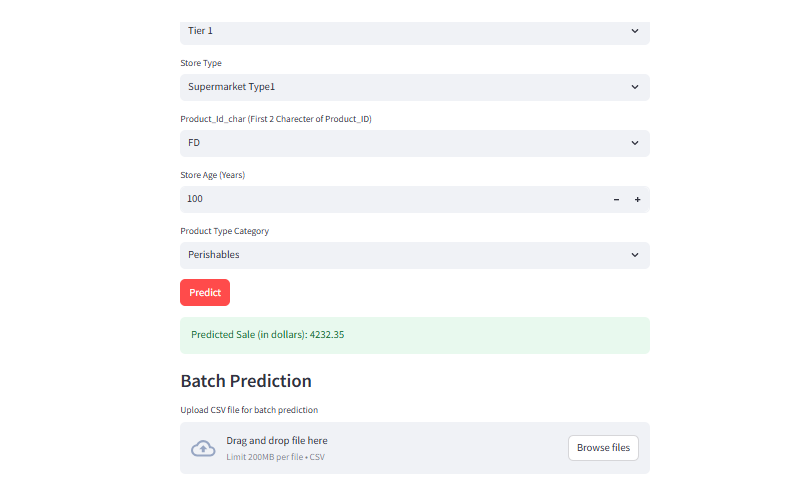

In [35]:
#App Single Prediction 2nd
display(Image(filename="/content/screenshots/App Single Prediction_2.png", width=1000))

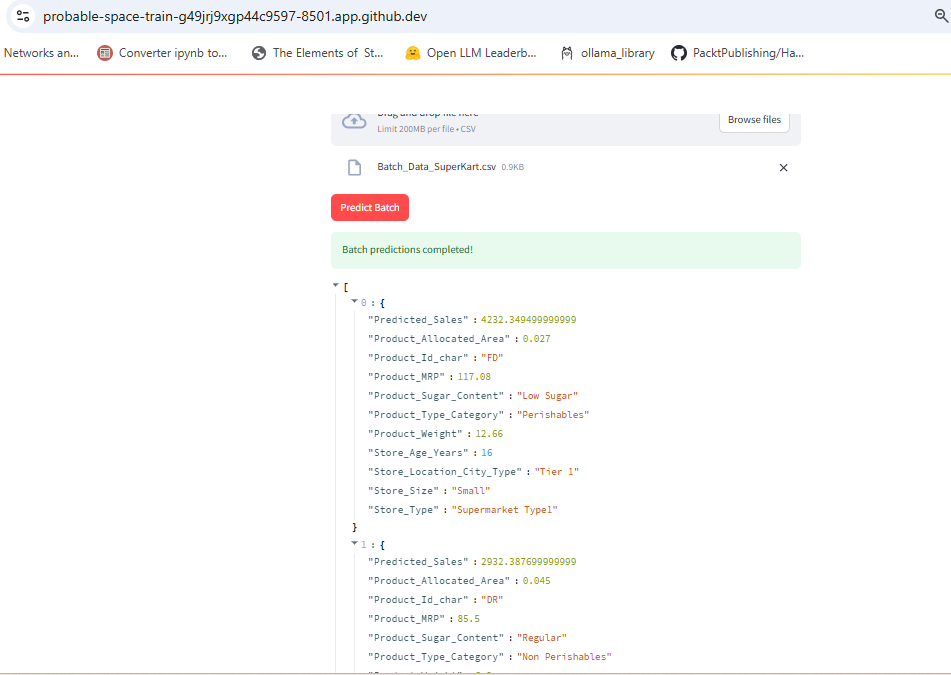

In [36]:
#App Batch Prediction
display(Image(filename="/content/screenshots/App Batch Prediction.png", width=1000))

# **Inferencing using Flask API**

As the ***frontend and backend are decoupled***, we can ***access the backend directly for predictions***.
- The decoupling ensures seamless interaction with the deployed model while leveraging the API for scalable inference.

Let's see how to interact with the deployed Flask API running inside a GitHub Codespace to perform **online** and **batch inference** from this Colab notebook.

We will:
1. Send API requests for both online and batch inference.
2. Process and check the model predictions.

**Before running the cells below**, make sure:
- Your Codespace is running with both containers up
- Port 7860 has been set to **Public** in the Codespace Ports tab
- You have copied the forwarded URL for port 7860
- You have also referred the document titled **`Guided Hands-on - Containerized Model Deployment using GitHub Codespaces`** provided

In [3]:
import json  # To handle JSON formatting for API requests and responses
import requests  # To send HTTP requests to the deployed Flask API

import pandas as pd  # For data manipulation and analysis
import numpy as np  # For numerical computations

In [15]:
# URL for port 7860
model_root_url = "https://probable-space-train-g49jrj9xgp44c9597-7860.app.github.dev/"

Replace the URL above with the actual forwarded URL from your Codespace's Ports tab. It will look something like `https://organic-space-abcd1234-7860.app.github.dev`. Make sure there is no trailing slash at the end.

This URL is a tunnel that Codespaces creates to route external HTTP requests into your Codespace and to the Flask container running on port 7860.

In [16]:
model_url = model_root_url + "/v1/superkart"  # Endpoint for online (single) inference

Since our model predictions are provided by the following endpoint we created using Flask, we need to invoke the same to make prediction.

> ```@superkart_api.post('/v1/superkart')```

In [17]:
model_batch_url = model_root_url + "/v1/superkartbatch"  # Endpoint for batch inference

> ```@superkart_api.post('/v1/superkartbatch')```

## Online

**Online Inference:** Sending a single request to the API and receiving an immediate response. This is useful for real-time applications like recommendation systems and fraud detection.  
* This data is sent as a JSON payload in a POST request to the model endpoint.

* The model processes the input features and returns a prediction.

In [18]:
payload = {
  "Product_Weight": 12.66,
  "Product_Sugar_Content": "Low Sugar",
  "Product_Allocated_Area": 0.027,
  "Product_MRP": 117.08,
  "Store_Size": "Medium",
  "Store_Location_City_Type": "Tier 2",
  "Store_Type": "Supermarket Type2",
  "Product_Id_char": "FD",
  "Store_Age_Years": 16,
  "Product_Type_Category": "Non Perishables"
}

In [19]:
# Sending a POST request to the model endpoint with the test payload
response = requests.post(model_url, json=payload)

In [20]:
response

<Response [200]>

`<Response [200]>` indicates that the HTTP request was successful.  

- `Response` is the object returned by `requests.post()`.  
- `[200]` is the HTTP status code, meaning **OK** (the request was processed successfully).  

In [21]:
print(response.json())

{'Predicted Sale (in dollars)': 2951.6}


`response.json()` is used to parse the response body as JSON.  
- If the API returns data in JSON format, `.json()` converts it into a Python dictionary.  
- This allows easy access to specific values using keys.  

## Batch

**Batch Inference:** Sending multiple inputs in a single request, allowing efficient processing of large datasets. This is ideal for analyzing historical data at scale.

In [24]:
batch_dataset = pd.read_csv("/content/ModelDeployment/Batch_Data_SuperKart.csv")

**Note**: The batch CSV file must contain all the feature columns expected by the model: `Product_Weight`, `Product_Sugar_Content`, `Product_Allocated_Area`, `Product_MRP`, `Store_Size`, `Store_Location_City_Type`, `Store_Type`, `Product_Id_char`, `Store_Age_Years`, `Product_Type_Category`.

In [25]:
# Prepare batch input for API request
batch_input = {
    'file': batch_dataset.to_csv(header=True, index=False).encode('utf-8')
}

This code prepares the product data as a **file-like object** to send in an API request (in the `files` parameter of `requests.post`).

- `batch_dataset`: This is a Pandas DataFrame containing the product data loaded from a CSV file.

- `.to_csv(header=True, index=False)`: Converts the DataFrame into a CSV **string**, keeping the column headers (`header=True`) but **excluding the index** (`index=False`).

- `.encode('utf-8')`: Encodes the CSV string into **bytes** (UTF-8 format), which is necessary for sending it over an HTTP request.

- `'file': ...`: Wraps the encoded CSV data in a dictionary with the key `'file'`, which is expected by the Flask backend.

In [26]:
# Send request to the model API for batch predictions
response = requests.post(
    model_batch_url,  # Model endpoint URL
    files=batch_input
)

This line sends a **POST request** to the deployed model API to perform **batch sales prediction**.

- `requests.post(...)`: This uses the `requests` library to make a **POST** request to a web server (in this case, our API endpoint for batch predictions).

- `model_batch_url`: This is the URL endpoint where the batch prediction API is hosted. It should look like this:\
  `"https://probable-space-train-g49jrj9xgp44c9597-7860.app.github.dev/v1/superkartbatch"`

- `files=batch_input`: This sends the batch data file (e.g., a CSV) as part of the request using the `files` parameter.

- `response`: This is the result of the API call and contains the response from the server, including predicted sales values.

In [27]:
response

<Response [200]>

In [28]:
# Extract predictions from API response
response.text

'[{"Predicted_Sales":4232.349499999999,"Product_Allocated_Area":0.027,"Product_Id_char":"FD","Product_MRP":117.08,"Product_Sugar_Content":"Low Sugar","Product_Type_Category":"Perishables","Product_Weight":12.66,"Store_Age_Years":16,"Store_Location_City_Type":"Tier 1","Store_Size":"Small","Store_Type":"Supermarket Type1"},{"Predicted_Sales":2932.387699999999,"Product_Allocated_Area":0.045,"Product_Id_char":"DR","Product_MRP":85.5,"Product_Sugar_Content":"Regular","Product_Type_Category":"Non Perishables","Product_Weight":8.2,"Store_Age_Years":22,"Store_Location_City_Type":"Tier 2","Store_Size":"Medium","Store_Type":"Supermarket Type2"},{"Predicted_Sales":3929.4952999999978,"Product_Allocated_Area":0.012,"Product_Id_char":"NC","Product_MRP":210.75,"Product_Sugar_Content":"No Sugar","Product_Type_Category":"Non Perishables","Product_Weight":15.4,"Store_Age_Years":8,"Store_Location_City_Type":"Tier 3","Store_Size":"High","Store_Type":"Departmental Store"},{"Predicted_Sales":1934.1287000000

As we can see, we receive a JSON where Predicted_Sales is predicted sales against the other set of values of all other variables.

%md
# Stopping and Cleaning Up

You can stop and remove the containers and network inside the Codespace terminal:

```
docker stop frontend backend
docker rm frontend backend
docker network rm rental-app-network
```

To stop the Codespace itself, go to [github.com/codespaces](https://github.com/codespaces) and click the three-dot menu next to Codespace, then select **Stop codespace**. If you no longer need it, you can delete it from the same menu to free up resources.

# **Actionable Insights and Business Recommendations**

1. **Flexibility and Scalability:**
   The decoupled frontend-backend architecture allows each component to be updated, maintained, and scaled independently. The Streamlit frontend can be enhanced without modifying the Flask API or ML model, while the backend can be scaled independently to handle increasing prediction requests. This provides greater flexibility and supports future business growth.
2. **Technology Agnostic Architecture:**
   The solution is not dependent on a specific frontend or backend technology. Currently, Streamlit is used for the user interface and Flask for serving the ML model through REST APIs. In the future, either component can be replaced with technologies better suited to enterprise requirements without rebuilding the underlying prediction model. This reduces technology lock-in and supports long-term adaptability.
3. **Portability and Reliable Deployment through Containers:**
   Docker containers package the ML model, Python dependencies, application code, and runtime environment into standardized, self-contained units. Deploying these containers within GitHub Codespaces provides a consistent environment and minimizes dependency and compatibility issues. The same containerized application can subsequently be deployed to other environments such as cloud platforms or enterprise infrastructure with minimal changes.
4. **Reusability and Integration Opportunities:**
   The Flask backend exposes the prediction functionality through REST APIs, allowing the same ML model to be consumed by multiple applications. For example, the API can support the Streamlit interface as well as future web applications, mobile applications, dashboards, or other business systems. This avoids duplicating prediction logic and maximizes the business value of the deployed ML model.

# **Overall Business Recommendation**
The current architecture provides a strong foundation for taking the **SuperKart sales prediction model from a standalone ML project to a reusable business service**. As adoption increases, the next steps **could include cloud deployment, API authentication, logging and monitoring, automated CI/CD, model versioning, and backend autoscaling** to make the solution production-ready.